In [1]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
tokenizer

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

BertTokenizerFast(name_or_path='bert-base-uncased', vocab_size=30522, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

In [2]:
!wget https://archive.ics.uci.edu/static/public/20/census+income.zip


--2025-04-17 12:28:46--  https://archive.ics.uci.edu/static/public/20/census+income.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘census+income.zip’

census+income.zip       [   <=>              ] 650.11K  1008KB/s    in 0.6s    

2025-04-17 12:28:47 (1008 KB/s) - ‘census+income.zip’ saved [665715]



In [3]:
!unzip census+income.zip

Archive:  census+income.zip
  inflating: adult.data              
  inflating: adult.names             
  inflating: adult.test              
  inflating: Index                   
  inflating: old.adult.names         


In [4]:
import pandas as pd

df = pd.read_csv('adult.data', names = ['age','workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'])
print(len(df))
df

32561


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [5]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

In [7]:
import numpy as np
import torch

DROP_P = 0.2

def concatenate_text(x_full):

    x = {}
    for i, j in x_full.items():
        x[i] = j if np.random.random() > DROP_P else '[UNK]'
        # print(i)
    # print(x)
    
    text = "".join([f"I have information about a person. ",
            f"He is {x['age'] if np.random.random() > DROP_P else '[UNK]'} years old. ",
            f"His sex is {x['sex']}. ",
            f"His workclass is {x['workclass']}. ",
            f"There are approximately {x['fnlwgt']} people in the US like him. ",
            f"His education is {x['education']}. ",
            f"His education duration is {x['education-num']} years. ",
            f"His marital status is {x['marital-status']}. ",
            f"His occupation is {x['occupation']}. ",
            f"His relationship is {x['relationship']}. ",
            f"His race is {x['race']}. ",
            f"His capital gain is {x['capital-gain']}. ",
            f"His capital loss is {x['capital-loss']}. ",
            f"He works {x['hours-per-week']} hours per week. ",
            f"His nativecountry is {x['native-country']}."])

    
    return text

concatenate_text(df.iloc[0])

'I have information about a person. He is [UNK] years old. His sex is [UNK]. His workclass is  State-gov. There are approximately 77516 people in the US like him. His education is  Bachelors. His education duration is 13 years. His marital status is  Never-married. His occupation is [UNK]. His relationship is  Not-in-family. His race is  White. His capital gain is 2174. His capital loss is 0. He works 40 hours per week. His nativecountry is [UNK].'

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.drop('income', axis =1),
                                                    df['income'],
                                                    test_size=.2,
                                                    random_state = 42)
y_train = y_train.replace({' >50K':1, ' <=50K':0})
y_test = y_test.replace({' >50K':1, ' <=50K':0})

X_train['text'] = X_train.apply(lambda x: concatenate_text(x), axis=1)
X_test['text'] = X_test.apply(lambda x: concatenate_text(x), axis=1)

X_train['label'] = y_train
X_test['label'] = y_test

<ipython-input-8-6dfd4ea84939>:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_train = y_train.replace({' >50K':1, ' <=50K':0})
<ipython-input-8-6dfd4ea84939>:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_test = y_test.replace({' >50K':1, ' <=50K':0})


In [9]:
X_train['text'].iloc[0]

'I have information about a person. He is 33 years old. His sex is  Female. His workclass is  Local-gov. There are approximately 198183 people in the US like him. His education is  Bachelors. His education duration is 13 years. His marital status is  Never-married. His occupation is  Prof-specialty. His relationship is  Not-in-family. His race is  White. His capital gain is 0. His capital loss is 0. He works 50 hours per week. His nativecountry is  United-States.'

In [10]:
len(X_train)

26048

In [11]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 2.6 MB/s eta 0:00:00


In [12]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import numpy as np
import evaluate

# Define label mappings
# id2label = {0: "NOT-DONATE", 1: "DONATE"}
# label2id = {"NOT-DONATE": 0, "DONATE": 1}

# Convert to Hugging Face Dataset format
train_dataset = Dataset.from_pandas(X_train)
test_dataset = Dataset.from_pandas(X_test)

def tokenize_function(examples):
    # Adjust based on the structure of your dataset
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=128)

tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

# Format the datasets correctly with labels
tokenized_train_dataset = tokenized_train_dataset.map(lambda x: {'labels': x['label']})
tokenized_test_dataset = tokenized_test_dataset.map(lambda x: {'labels': x['label']})

Map:   0%|          | 0/26048 [00:00<?, ? examples/s]

Map:   0%|          | 0/6513 [00:00<?, ? examples/s]

Map:   0%|          | 0/26048 [00:00<?, ? examples/s]

Map:   0%|          | 0/6513 [00:00<?, ? examples/s]

In [13]:
tokenized_train_dataset[0].keys()

dict_keys(['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'text', 'label', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'])

In [14]:
tokenized_train_dataset[0]['text']

'I have information about a person. He is 33 years old. His sex is  Female. His workclass is  Local-gov. There are approximately 198183 people in the US like him. His education is  Bachelors. His education duration is 13 years. His marital status is  Never-married. His occupation is  Prof-specialty. His relationship is  Not-in-family. His race is  White. His capital gain is 0. His capital loss is 0. He works 50 hours per week. His nativecountry is  United-States.'

In [15]:
tokenized_train_dataset[0]['label']

1

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Roc Auc
1,0.510300,0.543913,0.725704
2,0.538900,0.538856,0.725430
3,0.543700,0.537017,0.735033
4,0.536500,0.537572,0.741967
5,0.514600,0.530776,0.744925
6,0.565700,0.541936,0.750643
7,0.504800,0.520018,0.750487
8,0.512900,0.522256,0.753341
9,0.493900,0.517405,0.754835
10,0.543300,0.517050,0.755983


{'eval_loss': 0.51705002784729, 'eval_roc_auc': 0.7559829605859543, 'eval_runtime': 24.9371, 'eval_samples_per_second': 261.178, 'eval_steps_per_second': 4.09, 'epoch': 10.0}
test f1 0.0
test precision 0.0
test recall 0.0
test accuracy 0.0
test roc_auc 0.7557028816254548



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


train f1 0.0
train precision 0.0
train recall 0.0
train accuracy 0.7592905405405406
train roc_auc 0.7535330848656128


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


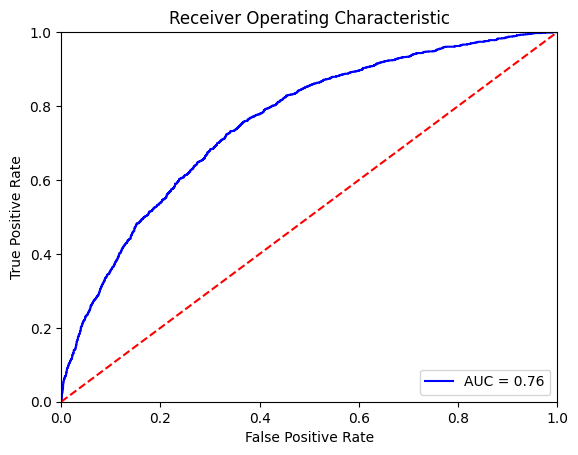

In [80]:
from transformers import BertForSequenceClassification
from transformers import DataCollatorWithPadding
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
from sklearn.metrics import roc_curve, auc
import sklearn.metrics as metrics
import matplotlib.pyplot as plt
import sklearn.metrics as metrics

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2).to('cuda')

model.dropout.p = 0

for param in model.bert.parameters():
    param.requires_grad = False

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=10,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=0,
    learning_rate = 0.001,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
print("test f1", f1_score(y_test, np.argmax(pred[0], 1)))
print("test precision", precision_score(y_test, np.argmax(pred[0], 1)))
print("test recall", recall_score(y_test, np.argmax(pred[0], 1)))
print("test accuracy", precision_score(y_test, np.argmax(pred[0], 1)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

Epoch,Training Loss,Validation Loss,Roc Auc
1,0.312400,0.325495,0.900313
2,0.329900,0.305884,0.912859
3,0.287700,0.310259,0.913012
4,0.307900,0.325110,0.911888
5,0.290300,0.304906,0.916095
6,0.300800,0.305746,0.913830
7,0.268100,0.307306,0.912479
8,0.297800,0.311854,0.912531
9,0.254600,0.327394,0.910005
10,0.295100,0.327323,0.909985


{'eval_loss': 0.32732319831848145, 'eval_roc_auc': 0.9099845927591378, 'eval_runtime': 24.949, 'eval_samples_per_second': 261.052, 'eval_steps_per_second': 4.088, 'epoch': 10.0}
test f1 0.6865092203170495
test precision 0.6980263157894737
test recall 0.6753660089115213
test accuracy 0.6980263157894737
test roc_auc 0.9101837199483455



train f1 0.7473529890861703
train precision 0.7636484687083888
train recall 0.7317384370015949
train accuracy 0.8809121621621622
train roc_auc 0.9387666374266318


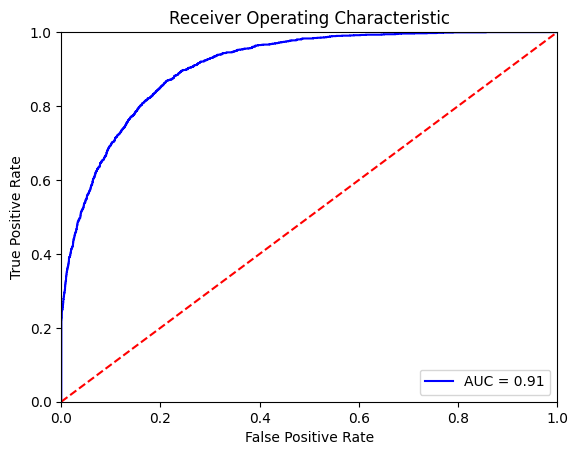

In [81]:
for param in model.bert.parameters():
    param.requires_grad = True

model.dropout.p = 0.0

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=10,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=0,
    learning_rate = 0.00001,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
print("test f1", f1_score(y_test, np.argmax(pred[0], 1)))
print("test precision", precision_score(y_test, np.argmax(pred[0], 1)))
print("test recall", recall_score(y_test, np.argmax(pred[0], 1)))
print("test accuracy", precision_score(y_test, np.argmax(pred[0], 1)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

<ipython-input-17-8fcfdad5b76f>:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_train = y_train.replace({' >50K':1, ' <=50K':0})
<ipython-input-17-8fcfdad5b76f>:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_test = y_test.replace({' >50K':1, ' <=50K':0})


Map:   0%|          | 0/26048 [00:00<?, ? examples/s]

Map:   0%|          | 0/6513 [00:00<?, ? examples/s]

Map:   0%|          | 0/26048 [00:00<?, ? examples/s]

Map:   0%|          | 0/6513 [00:00<?, ? examples/s]

...

Epoch,Training Loss,Validation Loss,Roc Auc
1,0.514400,0.549020,0.644197
2,0.542700,0.545584,0.646459
3,0.563800,0.560267,0.657353
4,0.556300,0.555921,0.664191
5,0.533300,0.551359,0.672775
6,0.577700,0.567751,0.678853
7,0.519400,0.537625,0.674931
8,0.525900,0.542244,0.679192
9,0.505300,0.536897,0.679557
10,0.562200,0.536676,0.681378


{'eval_loss': 0.5366760492324829, 'eval_roc_auc': 0.681378271849057, 'eval_runtime': 24.1142, 'eval_samples_per_second': 270.09, 'eval_steps_per_second': 4.23, 'epoch': 10.0}
test f1 0.0
test precision 0.0
test recall 0.0
test accuracy 0.0
test roc_auc 0.6762045713729292



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


train f1 0.0
train precision 0.0
train recall 0.0
train accuracy 0.7592905405405406
train roc_auc 0.6925801153570179


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


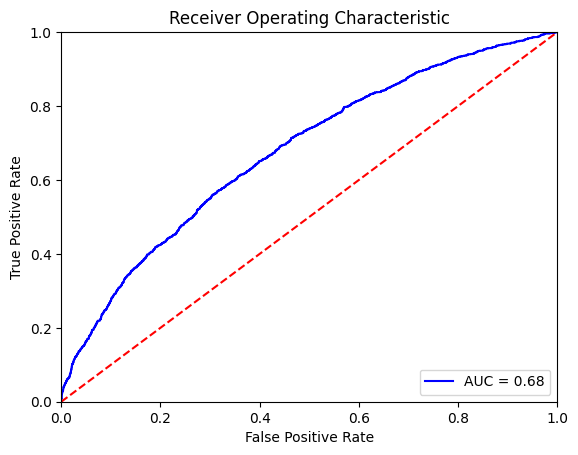

In [17]:
DROP_P = 0.5

X_train, X_test, y_train, y_test = train_test_split(df.drop('income', axis =1),
                                                    df['income'],
                                                    test_size=.2,
                                                    random_state = 42)
y_train = y_train.replace({' >50K':1, ' <=50K':0})
y_test = y_test.replace({' >50K':1, ' <=50K':0})

X_train['text'] = X_train.apply(lambda x: concatenate_text(x), axis=1)
X_test['text'] = X_test.apply(lambda x: concatenate_text(x), axis=1)

X_train['label'] = y_train
X_test['label'] = y_test

train_dataset = Dataset.from_pandas(X_train)
test_dataset = Dataset.from_pandas(X_test)

tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

# Format the datasets correctly with labels
tokenized_train_dataset = tokenized_train_dataset.map(lambda x: {'labels': x['label']})
tokenized_test_dataset = tokenized_test_dataset.map(lambda x: {'labels': x['label']})

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2).to('cuda')

model.dropout.p = 0

for param in model.bert.parameters():
    param.requires_grad = False

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=10,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=0,
    learning_rate = 0.001,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
print("test f1", f1_score(y_test, np.argmax(pred[0], 1)))
print("test precision", precision_score(y_test, np.argmax(pred[0], 1)))
print("test recall", recall_score(y_test, np.argmax(pred[0], 1)))
print("test accuracy", precision_score(y_test, np.argmax(pred[0], 1)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

Epoch,Training Loss,Validation Loss,Roc Auc
1,0.376400,0.391792,0.853358
2,0.390900,0.379324,0.867031
3,0.342100,0.371040,0.870691
4,0.351100,0.384184,0.870388
5,0.351300,0.363722,0.874606
6,0.369800,0.369412,0.872234
7,0.320800,0.366757,0.871982
8,0.361700,0.369267,0.871008
9,0.313300,0.375941,0.870247
10,0.372200,0.379410,0.868233


{'eval_loss': 0.3794103264808655, 'eval_roc_auc': 0.8682331210082791, 'eval_runtime': 24.1143, 'eval_samples_per_second': 270.089, 'eval_steps_per_second': 4.23, 'epoch': 10.0}
test f1 0.5985748218527315
test precision 0.6409883720930233
test recall 0.5614258434118395
test accuracy 0.6409883720930233
test roc_auc 0.8684389458778482



train f1 0.6715527526845065
train precision 0.7210834553440703
train recall 0.6283891547049442
train accuracy 0.8520423832923832
train roc_auc 0.9037006102667844


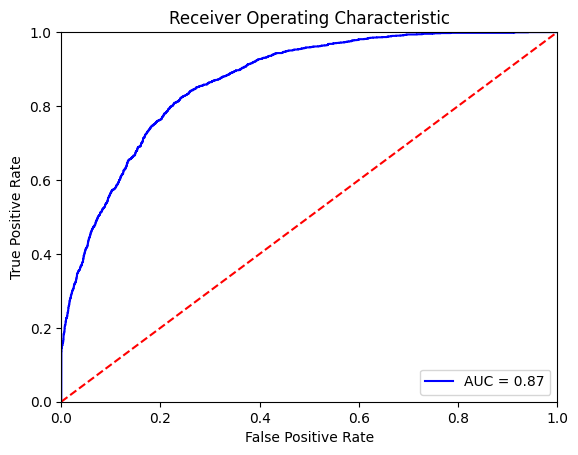

In [18]:
for param in model.bert.parameters():
    param.requires_grad = True

model.dropout.p = 0.0

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=10,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=0,
    learning_rate = 0.00001,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
print("test f1", f1_score(y_test, np.argmax(pred[0], 1)))
print("test precision", precision_score(y_test, np.argmax(pred[0], 1)))
print("test recall", recall_score(y_test, np.argmax(pred[0], 1)))
print("test accuracy", precision_score(y_test, np.argmax(pred[0], 1)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

<ipython-input-19-e8c8a4c0eb30>:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_train = y_train.replace({' >50K':1, ' <=50K':0})
<ipython-input-19-e8c8a4c0eb30>:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_test = y_test.replace({' >50K':1, ' <=50K':0})


Map:   0%|          | 0/26048 [00:00<?, ? examples/s]

Map:   0%|          | 0/6513 [00:00<?, ? examples/s]

Map:   0%|          | 0/26048 [00:00<?, ? examples/s]

Map:   0%|          | 0/6513 [00:00<?, ? examples/s]

...

Epoch,Training Loss,Validation Loss,Roc Auc
1,0.518900,0.554270,0.526279
2,0.554800,0.553727,0.566771
3,0.568100,0.562807,0.552980
4,0.564800,0.561855,0.561894
5,0.548000,0.557963,0.560533
6,0.588000,0.584182,0.560926
7,0.537800,0.551537,0.551504
8,0.543700,0.559662,0.554230
9,0.520600,0.552119,0.562633
10,0.571900,0.551795,0.560925


{'eval_loss': 0.5517954230308533, 'eval_roc_auc': 0.5609253850071394, 'eval_runtime': 24.1714, 'eval_samples_per_second': 269.451, 'eval_steps_per_second': 4.22, 'epoch': 10.0}
test f1 0.0
test precision 0.0
test recall 0.0
test accuracy 0.0
test roc_auc 0.548459842640576



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


train f1 0.0
train precision 0.0
train recall 0.0
train accuracy 0.7592905405405406
train roc_auc 0.5586575743544412


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


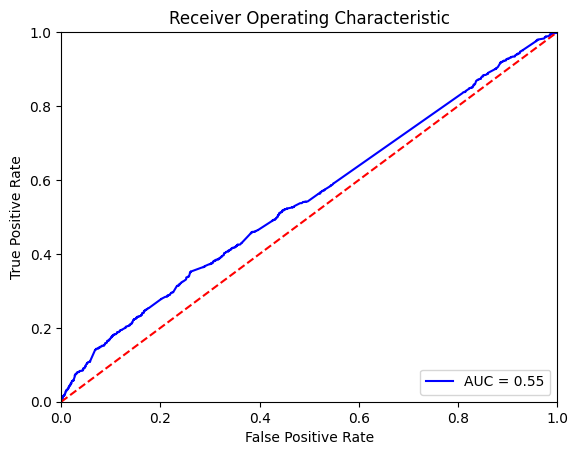

In [19]:
DROP_P = 0.9

X_train, X_test, y_train, y_test = train_test_split(df.drop('income', axis =1),
                                                    df['income'],
                                                    test_size=.2,
                                                    random_state = 42)
y_train = y_train.replace({' >50K':1, ' <=50K':0})
y_test = y_test.replace({' >50K':1, ' <=50K':0})

X_train['text'] = X_train.apply(lambda x: concatenate_text(x), axis=1)
X_test['text'] = X_test.apply(lambda x: concatenate_text(x), axis=1)

X_train['label'] = y_train
X_test['label'] = y_test

train_dataset = Dataset.from_pandas(X_train)
test_dataset = Dataset.from_pandas(X_test)

tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

# Format the datasets correctly with labels
tokenized_train_dataset = tokenized_train_dataset.map(lambda x: {'labels': x['label']})
tokenized_test_dataset = tokenized_test_dataset.map(lambda x: {'labels': x['label']})

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2).to('cuda')

model.dropout.p = 0

for param in model.bert.parameters():
    param.requires_grad = False

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=10,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=0,
    learning_rate = 0.001,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
print("test f1", f1_score(y_test, np.argmax(pred[0], 1)))
print("test precision", precision_score(y_test, np.argmax(pred[0], 1)))
print("test recall", recall_score(y_test, np.argmax(pred[0], 1)))
print("test accuracy", precision_score(y_test, np.argmax(pred[0], 1)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

Epoch,Training Loss,Validation Loss,Roc Auc
1,0.496600,0.515194,0.663878
2,0.515200,0.502811,0.687008
3,0.504300,0.506365,0.686322
4,0.500900,0.503568,0.687528
5,0.489400,0.499783,0.688050
6,0.549700,0.500847,0.687297
7,0.476200,0.507812,0.689489
8,0.475200,0.502654,0.691887
9,0.456000,0.507757,0.690287
10,0.492200,0.508291,0.688920


{'eval_loss': 0.5082905292510986, 'eval_roc_auc': 0.6889199243368203, 'eval_runtime': 24.2447, 'eval_samples_per_second': 268.636, 'eval_steps_per_second': 4.207, 'epoch': 10.0}
test f1 0.23248882265275708
test precision 0.5294117647058824
test recall 0.14894971355824316
test accuracy 0.5294117647058824
test roc_auc 0.6841088002110286



train f1 0.27414646528747305
train precision 0.6712243629583592
train recall 0.1722488038277512
train accuracy 0.7804437960687961
train roc_auc 0.7145891363835544


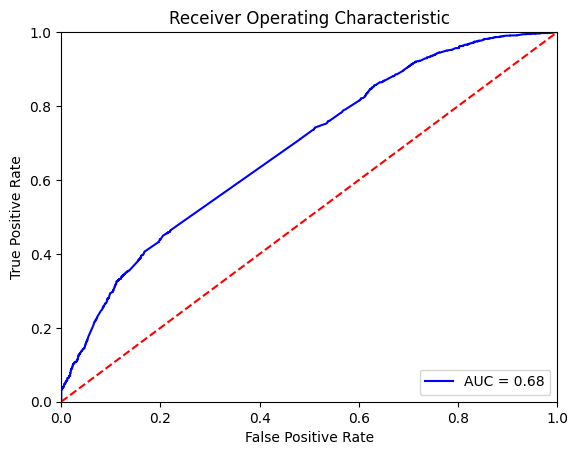

In [20]:
for param in model.bert.parameters():
    param.requires_grad = True

model.dropout.p = 0.0

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=10,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=0,
    learning_rate = 0.00001,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
print("test f1", f1_score(y_test, np.argmax(pred[0], 1)))
print("test precision", precision_score(y_test, np.argmax(pred[0], 1)))
print("test recall", recall_score(y_test, np.argmax(pred[0], 1)))
print("test accuracy", precision_score(y_test, np.argmax(pred[0], 1)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()